# Isolation Forest — Anomaly-Based Network Intrusion Detection

Unsupervised anomaly detection using **Isolation Forest** on the CICIDS2017 dataset.  
Trained on **benign-only** traffic, evaluated on unseen Friday attacks (DDoS, PortScan, Bot).  
Same data pipeline and evaluation framework as the denoising autoencoder for direct comparison.

**Key difference**: The autoencoder detects anomalies via high reconstruction error.  
Isolation Forest detects anomalies by how quickly a sample can be **isolated** via random splits — anomalous points require fewer splits.

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, accuracy_score,
                             roc_curve, roc_auc_score, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [9]:
# ── Paths ──────────────────────────────────────────────────────
TRAIN_PATH = Path("train_us.parquet")
TEST_PATH  = Path("test_us.parquet")
OUT_DIR    = ""
MODEL_OUT  = "isolation_forest.joblib"

SEED = 42

In [10]:

import os
print(f"File size: {os.path.getsize('train_us.parquet') / (1024*1024):.2f} MB")

File size: 265.17 MB


## 1. Data Loading

In [11]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

# Filter benign-only for training (same as autoencoder)
benign_df = train_df[train_df['Attack'] == 0].drop(columns=['Attack'])
print(f"\nBenign samples for training: {len(benign_df)}")

# Prepare test set — keep all (benign + attacks)
X_test = test_df.drop(columns=['Attack'])
y_test = test_df['Attack'].values

# Binary labels: 0 = benign, 1 = attack
true_labels = (y_test != 0).astype(int)

attack_names = {0: "BENIGN", 1: "Bot", 2: "Brute Force", 3: "DDoS",
                4: "DoS", 5: "PortScan", 6: "Web Attack"}

print(f"\nTest set composition:")
for attack_id in sorted(test_df['Attack'].unique()):
    name = attack_names.get(attack_id, f"Attack_{attack_id}")
    count = (y_test == attack_id).sum()
    print(f"  {name:15s}: {count:>8,}")

Train shape: (1919236, 70)
Test shape:  (573399, 70)

Benign samples for training: 1720966

Test set composition:
  BENIGN         :  395,106
  Bot            :      981
  DDoS           :   98,022
  PortScan       :   79,290


## 2. Train Isolation Forest

Isolation Forest isolates observations by randomly selecting a feature and a split value.  
Anomalies are "few and different" — they get isolated in fewer splits than normal points.

| Parameter | Description |
|-----------|-------------|
| `n_estimators` | Number of isolation trees (more = more stable scores) |
| `max_samples` | Samples per tree (`auto` = min(256, n_samples)) |
| `contamination` | Expected proportion of anomalies in training data |
| `max_features` | Features per tree (1.0 = all features) |

In [28]:
from itertools import product

param_grid = {
    'max_samples': [256, 512, 1024, 2048],
    'max_features': [0.5, 0.7, 0.8, 1.0],
    'n_estimators': [100, 200, 300],
}

results = []
best_model = None
best_auc = 0
for ms, mf, ne in product(param_grid['max_samples'],
                           param_grid['max_features'],
                           param_grid['n_estimators']):
    iforest = IsolationForest(
        max_samples=ms, max_features=mf, n_estimators=ne,
        contamination=0.01, random_state=42, n_jobs=-1
    )
    iforest.fit(benign_df)
    scores = -iforest.decision_function(X_test)
    auc = roc_auc_score(true_labels, scores)
    results.append((ms, mf, ne, auc))

    if auc > best_auc:          # ← track the best model
        best_auc = auc
        best_model = iforest    # ← keeps the actual fitted model
    print(f"max_samples={ms:>5}, max_features={mf:.1f}, n_estimators={ne:>3} → AUC: {auc:.4f}")



print(f"\nBest AUC: {best_auc:.4f}")

# Now best_model is the actual trained IF you can use for evaluation
joblib.dump(best_model, MODEL_OUT)



max_samples=  256, max_features=0.5, n_estimators=100 → AUC: 0.6516
max_samples=  256, max_features=0.5, n_estimators=200 → AUC: 0.6602
max_samples=  256, max_features=0.5, n_estimators=300 → AUC: 0.6728
max_samples=  256, max_features=0.7, n_estimators=100 → AUC: 0.6540
max_samples=  256, max_features=0.7, n_estimators=200 → AUC: 0.6600
max_samples=  256, max_features=0.7, n_estimators=300 → AUC: 0.6471
max_samples=  256, max_features=0.8, n_estimators=100 → AUC: 0.6577
max_samples=  256, max_features=0.8, n_estimators=200 → AUC: 0.6620
max_samples=  256, max_features=0.8, n_estimators=300 → AUC: 0.6726
max_samples=  256, max_features=1.0, n_estimators=100 → AUC: 0.6648
max_samples=  256, max_features=1.0, n_estimators=200 → AUC: 0.6838
max_samples=  256, max_features=1.0, n_estimators=300 → AUC: 0.6743
max_samples=  512, max_features=0.5, n_estimators=100 → AUC: 0.6775
max_samples=  512, max_features=0.5, n_estimators=200 → AUC: 0.6782
max_samples=  512, max_features=0.5, n_estimator

['isolation_forest.joblib']

## 3. Compute Anomaly Scores

`decision_function()` returns the anomaly score:  
- **Negative** = more anomalous (isolated in fewer splits)  
- **Positive** = more normal  

We **negate** the scores so that **higher = more anomalous** (consistent with autoencoder reconstruction errors).

In [29]:
# Anomaly scores on test set (negate so higher = more anomalous)
test_scores = -best_model.decision_function(X_test)

# Also compute on benign training data for reference
train_scores = -best_model.decision_function(benign_df)

print(f"Test scores  — mean: {test_scores.mean():.6f}, std: {test_scores.std():.6f}")
print(f"             — min: {test_scores.min():.6f}, max: {test_scores.max():.6f}")
print(f"Train scores — mean: {train_scores.mean():.6f}, std: {train_scores.std():.6f}")

Test scores  — mean: -0.192491, std: 0.090127
             — min: -0.259317, max: 0.198180
Train scores — mean: -0.221757, std: 0.052561


## 4. ROC AUC Analysis & F1-Optimal Threshold

Same evaluation framework as the autoencoder — ROC AUC measures threshold-independent separation quality, then F1-optimal threshold finds the best operating point.

In [30]:
# ROC curve and AUC
fpr, tpr, thresholds_roc = roc_curve(true_labels, test_scores)
auc_score = roc_auc_score(true_labels, test_scores)
print(f"ROC AUC Score: {auc_score:.4f}")

ROC AUC Score: 0.7156


In [31]:
# F1-optimal threshold
precisions, recalls, thresholds_pr = precision_recall_curve(true_labels, test_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds_pr[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]

print(f"\nF1-Optimal Threshold: {best_f1_threshold:.6f}")
print(f"  Precision: {precisions[best_f1_idx]:.4f}")
print(f"  Recall:    {recalls[best_f1_idx]:.4f}")
print(f"  F1-Score:  {best_f1:.4f}")


F1-Optimal Threshold: -0.233762
  Precision: 0.4850
  Recall:    0.9077
  F1-Score:  0.6322


In [32]:
# Recall vs FPR tradeoff table
print("Recall vs False Positive Rate Tradeoff:")
print("-" * 50)
threshold_sweep = np.linspace(test_scores.max(), test_scores.min(), 10000)
for target_recall in [0.5, 0.6, 0.7, 0.8, 0.9]:
    for t in threshold_sweep:
        preds_t = (test_scores > t).astype(int)
        rec = preds_t[true_labels == 1].mean()
        if rec >= target_recall:
            fpr_t = preds_t[true_labels == 0].mean()
            print(f"  Recall {target_recall:.0%} \u2192 threshold: {t:.6f}, FPR: {fpr_t:.2%}")
            break
    else:
        print(f"  Recall {target_recall:.0%} \u2192 not achievable")

Recall vs False Positive Rate Tradeoff:
--------------------------------------------------
  Recall 50% → threshold: -0.224178, FPR: 36.33%
  Recall 60% → threshold: -0.228708, FPR: 40.31%
  Recall 70% → threshold: -0.230080, FPR: 41.23%
  Recall 80% → threshold: -0.232963, FPR: 43.02%
  Recall 90% → threshold: -0.233695, FPR: 43.44%


## 5. Evaluation with F1-Optimal Threshold

In [33]:
# Binary classification with F1-optimal threshold
predictions = (test_scores > best_f1_threshold).astype(int)

report = classification_report(true_labels, predictions,
                               target_names=["Benign", "Anomaly"],
                               zero_division=0)
print("Binary Classification Report (F1-Optimal Threshold):")
print(report)

accuracy = accuracy_score(true_labels, predictions)
print(f"Overall Accuracy: {accuracy:.4f}")

Binary Classification Report (F1-Optimal Threshold):
              precision    recall  f1-score   support

      Benign       0.93      0.57      0.70    395106
     Anomaly       0.48      0.91      0.63    178293

    accuracy                           0.67    573399
   macro avg       0.71      0.74      0.67    573399
weighted avg       0.79      0.67      0.68    573399

Overall Accuracy: 0.6709


In [34]:
# Per-attack-type recall
per_attack_results = {}
print("Per-Attack-Type Recall (F1-Optimal Threshold):")
print("-" * 40)
for attack_id in sorted(test_df['Attack'].unique()):
    mask = y_test == attack_id
    name = attack_names.get(attack_id, f"Attack_{attack_id}")
    count = mask.sum()
    if attack_id == 0:
        recall = 1 - predictions[mask].mean()
        print(f"  {name:15s} | Correctly identified: {recall:.4f} | Count: {count}")
    else:
        recall = predictions[mask].mean()
        print(f"  {name:15s} | Recall: {recall:.4f} | Count: {count}")
    per_attack_results[name] = {'recall': recall, 'count': count}

Per-Attack-Type Recall (F1-Optimal Threshold):
----------------------------------------
  BENIGN          | Correctly identified: 0.5651 | Count: 395106
  Bot             | Recall: 0.3925 | Count: 981
  DDoS            | Recall: 0.8397 | Count: 98022
  PortScan        | Recall: 0.9928 | Count: 79290


In [35]:
# Save reports
with open("classification_reports.txt", "w") as f:
    f.write(f"Binary Classification Report (F1-Optimal Threshold: {best_f1_threshold:.6f})\n")
    f.write("=" * 50 + "\n")
    f.write(report + "\n")
    f.write(f"ROC AUC: {auc_score:.4f}\n\n")
    f.write("Per-Attack-Type Recall (F1-Optimal Threshold)\n")
    f.write("=" * 50 + "\n")
    for name, res in per_attack_results.items():
        f.write(f"  {name:15s} | Recall: {res['recall']:.4f} | Count: {res['count']}\n")

with open("threshold.txt", "w") as f:
    f.write(f"ROC AUC: {auc_score:.6f}\n")
    f.write(f"F1-optimal threshold: {best_f1_threshold:.6f}\n")
    f.write(f"F1-optimal F1-score: {best_f1:.4f}\n")
    f.write(f"F1-optimal precision: {precisions[best_f1_idx]:.4f}\n")
    f.write(f"F1-optimal recall: {recalls[best_f1_idx]:.4f}\n")

print(f"Saved reports to: {OUT_DIR}")

Saved reports to: 


## 6. Plots

Saved: anomaly_score_distribution.png


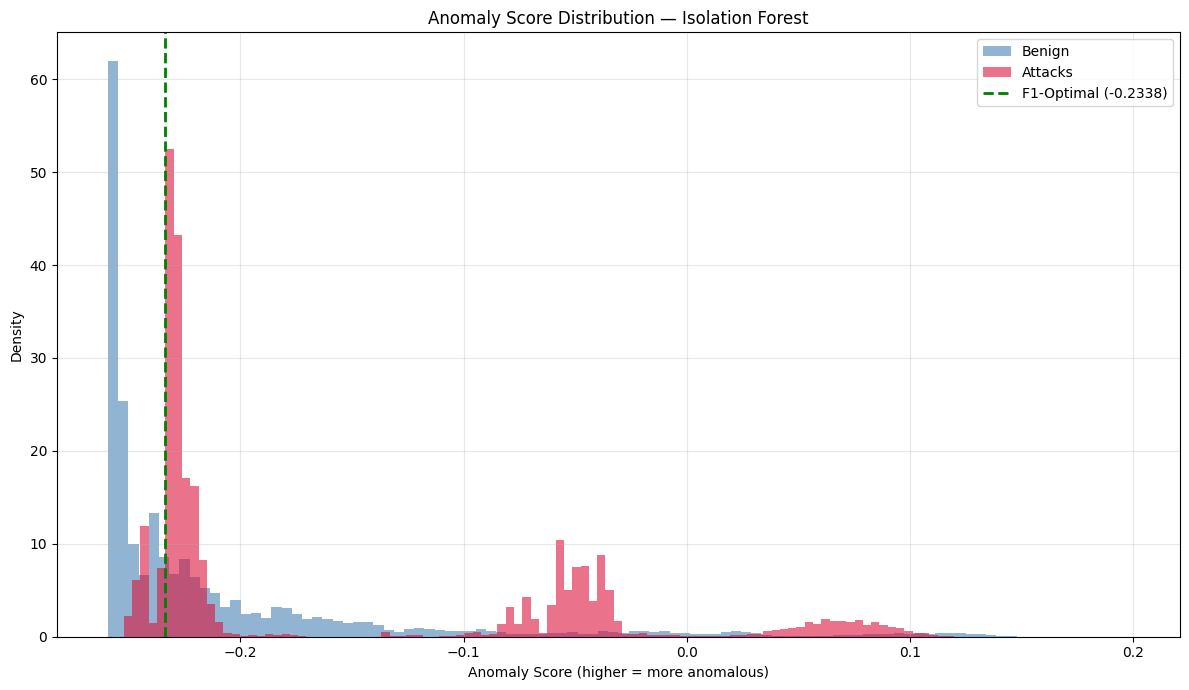

In [36]:
# Anomaly Score Distribution — Benign vs Attacks
plt.figure(figsize=(12, 7))

benign_scores = test_scores[y_test == 0]
attack_scores = test_scores[y_test != 0]

plt.hist(benign_scores, bins=100, alpha=0.6, label='Benign', color='steelblue', density=True)
plt.hist(attack_scores, bins=100, alpha=0.6, label='Attacks', color='crimson', density=True)
plt.axvline(best_f1_threshold, color='green', linestyle='--', linewidth=2,
            label=f'F1-Optimal ({best_f1_threshold:.4f})')

plt.title('Anomaly Score Distribution \u2014 Isolation Forest')
plt.xlabel('Anomaly Score (higher = more anomalous)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = "anomaly_score_distribution.png"
plt.savefig(out_path)
print(f"Saved: {out_path}")
plt.show()

Saved: roc_curve.png


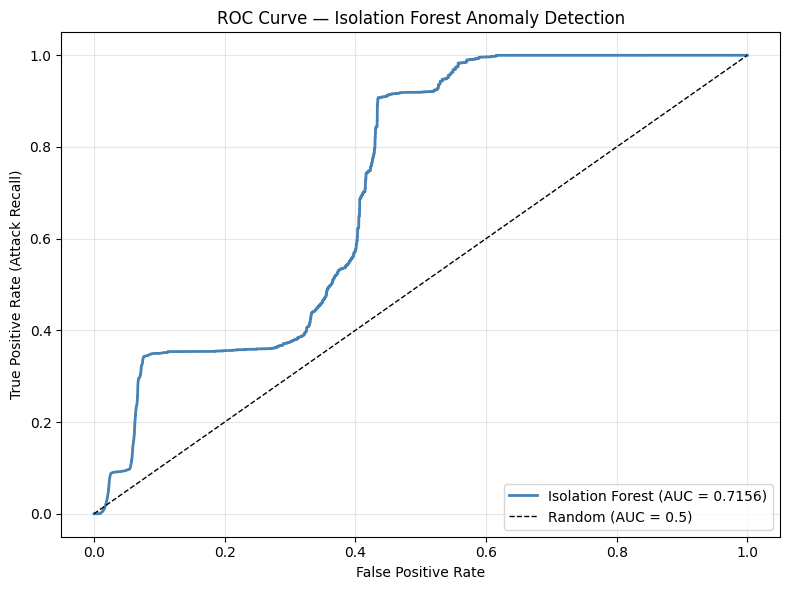

In [37]:
# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Isolation Forest (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

plt.title('ROC Curve \u2014 Isolation Forest Anomaly Detection')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Attack Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = "roc_curve.png"
plt.savefig(out_path)
print(f"Saved: {out_path}")
plt.show()

Saved: precision_recall_curve.png


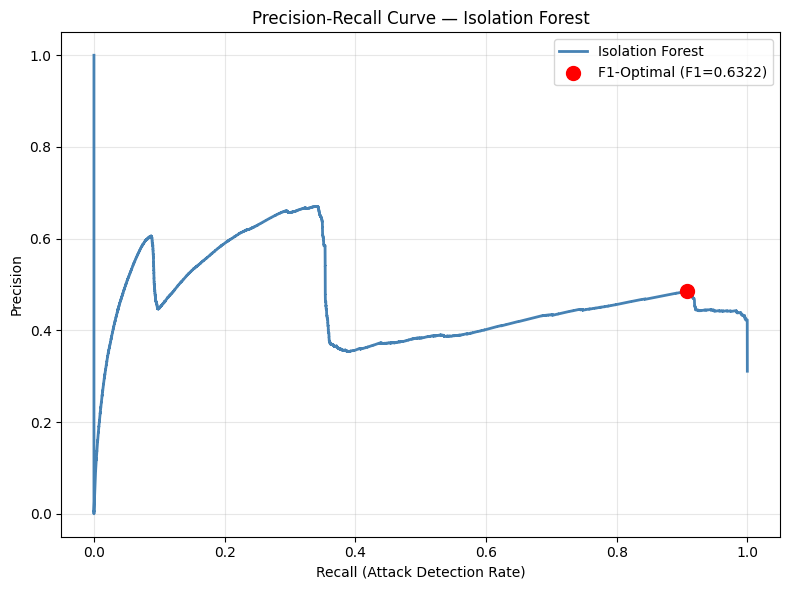

In [38]:
# Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='steelblue', linewidth=2, label='Isolation Forest')
plt.scatter(recalls[best_f1_idx], precisions[best_f1_idx],
            color='red', s=100, zorder=5,
            label=f'F1-Optimal (F1={best_f1:.4f})')

plt.title('Precision-Recall Curve \u2014 Isolation Forest')
plt.xlabel('Recall (Attack Detection Rate)')
plt.ylabel('Precision')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

out_path = "precision_recall_curve.png"
plt.savefig(out_path)
print(f"Saved: {out_path}")
plt.show()

Saved: per_attack_recall.png


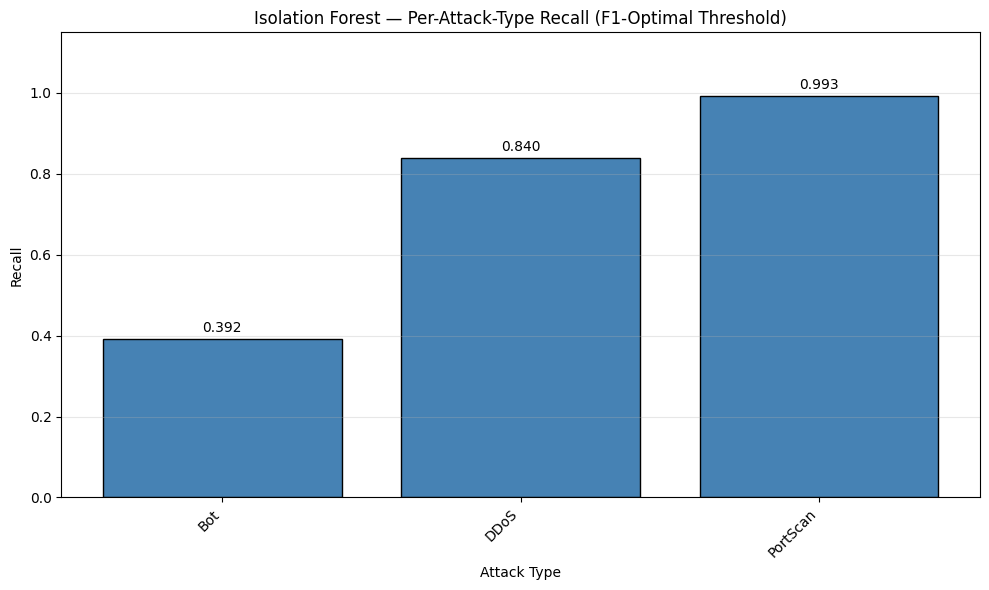

In [39]:
# Per-Attack Recall Bar Chart
names = [k for k in per_attack_results if k != "BENIGN"]
recall_vals = [per_attack_results[k]['recall'] for k in names]

plt.figure(figsize=(10, 6))
bars = plt.bar(names, recall_vals, color='steelblue', edgecolor='black')

for bar, val in zip(bars, recall_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', va='bottom', fontsize=10)

plt.title('Isolation Forest \u2014 Per-Attack-Type Recall (F1-Optimal Threshold)')
plt.xlabel('Attack Type')
plt.ylabel('Recall')
plt.ylim(0, 1.15)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

out_path = "per_attack_recall.png"
plt.savefig(out_path)
print(f"Saved: {out_path}")
plt.show()